# Setup

In [1]:
import os, sys, warnings
from pathlib import Path

PROJECT = Path.home() / "Desktop" / "Project" / "sales-forecasting-assistant"
os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))
(PROJECT / "docs" / "images").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")
print("Working in:", os.getcwd())

Working in: /Users/dayoawe1/Desktop/Project/sales-forecasting-assistant


# Install Prophet (one time only)

In [ ]:
%pip install prophet

# Load the features from Snowflake

In [2]:
import numpy as np
import pandas as pd
from src.ingest.load_raw import get_connection

conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT * FROM SALES_DB.ANALYTICS.FEATURES")
df = cur.fetch_pandas_all()
conn.close()

df["WEEK_START"] = pd.to_datetime(df["WEEK_START"])
numeric_cols = [c for c in df.columns if c not in ("FAMILY", "STORE_TYPE", "WEEK_START")]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df = df.sort_values(["STORE_NBR", "FAMILY", "WEEK_START"]).reset_index(drop=True)

print(df.shape)
df.head()

(427680, 20)


,STORE_NBR,FAMILY,WEEK_START,STORE_TYPE,STORE_CLUSTER,SALES,PROMO_ITEMS,HOLIDAY_DAYS,AVG_OIL_PRICE,STORE_TRANSACTIONS,SALES_LAG_1,SALES_LAG_2,SALES_LAG_4,SALES_LAG_52,SALES_ROLL_MEAN_4,SALES_ROLL_MEAN_12,SALES_ROLL_STD_12,WEEK_OF_YEAR,MONTH,YEAR
0,1,AUTOMOTIVE,2013-01-07,D,13,13.0,0,0,93.442857,11093.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,2013
1,1,AUTOMOTIVE,2013-01-14,D,13,13.0,0,0,94.875714,10820.0,13.0,NaN,NaN,NaN,13.0,13.0,NaN,3,1,2013
2,1,AUTOMOTIVE,2013-01-21,D,13,16.0,0,0,95.365714,10628.0,13.0,13.0,NaN,NaN,13.0,13.0,0.000000,4,1,2013
3,1,AUTOMOTIVE,2013-01-28,D,13,14.0,0,0,97.368571,10808.0,16.0,13.0,NaN,NaN,14.0,14.0,1.732051,5,1,2013
4,1,AUTOMOTIVE,2013-02-04,D,13,14.0,0,0,96.042857,10425.0,14.0,16.0,13.0,NaN,14.0,14.0,1.414214,6,2,2013


# Test weeks, metrics, and helper functions

In [3]:
KEYS = ["STORE_NBR", "FAMILY", "WEEK_START"]

# The last 8 full weeks are the test period
test_weeks = [pd.Timestamp(w) for w in sorted(df["WEEK_START"].unique())[-8:]]

# The 10 biggest series (store x family) by total sales
top_series = df.groupby(["STORE_NBR", "FAMILY"])["SALES"].sum().nlargest(10).index
top_list = list(top_series)

# Rows we will forecast
test = df[df["WEEK_START"].isin(test_weeks)].copy()
test["IS_TOP"] = pd.MultiIndex.from_frame(test[["STORE_NBR", "FAMILY"]]).isin(top_series)

def wape(actual, forecast):
    a, f = np.asarray(actual, float), np.asarray(forecast, float)
    return np.abs(a - f).sum() / np.abs(a).sum()

def rmse(actual, forecast):
    a, f = np.asarray(actual, float), np.asarray(forecast, float)
    return np.sqrt(np.mean((a - f) ** 2))

results = []

def add_preds(rows, col):
    """Attach a model's predictions to the test table (safe to re-run)."""
    global test
    p = pd.DataFrame(rows)
    test = test.drop(columns=[col], errors="ignore").merge(p, on=KEYS, how="left")

def record(model, col):
    """Score a model on all series (if available) and on the top 10."""
    global results
    results = [r for r in results if r["model"] != model]
    for scope, sub in [("all", test), ("top10", test[test["IS_TOP"]])]:
        sub = sub[sub[col].notna()]
        if scope == "all" and len(sub) < len(test):
            continue
        results.append({"model": model, "scope": scope, "n": len(sub),
                        "wape": wape(sub["SALES"], sub[col]),
                        "rmse": rmse(sub["SALES"], sub[col])})

print("Test weeks:", [w.date() for w in test_weeks])
print("Top 10 series:")
for s in top_list:
    print("  ", s)

Test weeks: [datetime.date(2017, 6, 19), datetime.date(2017, 6, 26), datetime.date(2017, 7, 3), datetime.date(2017, 7, 10), datetime.date(2017, 7, 17), datetime.date(2017, 7, 24), datetime.date(2017, 7, 31), datetime.date(2017, 8, 7)]
Top 10 series:
   (44, 'GROCERY I')
   (45, 'GROCERY I')
   (47, 'GROCERY I')
   (46, 'GROCERY I')
   (44, 'BEVERAGES')
   (3, 'GROCERY I')
   (48, 'GROCERY I')
   (45, 'BEVERAGES')
   (3, 'BEVERAGES')
   (49, 'GROCERY I')


### Why WAPE and not MAPE: many weeks have zero sales, and MAPE divides by the actual value, which breaks when it's zero. WAPE measures total error relative to total sales.

# Baseline, seasonal naive (same week last year)

In [4]:
test["PRED_NAIVE52"] = test["SALES_LAG_52"].fillna(0)
record("naive_52", "PRED_NAIVE52")
pd.DataFrame(results)

,model,scope,n,wape,rmse
0,naive_52,all,14256,0.159997,2204.659340
1,naive_52,top10,80,0.135833,10041.311486


# ARIMA with yearly seasonality (top 10 series)

###### Full seasonal ARIMA with a 52-week cycle is very slow, so this uses a standard workaround: ARIMA(1,1,1) plus Fourier terms (sine and cosine waves) to capture the yearly pattern.

In [5]:
from statsmodels.tsa.arima.model import ARIMA

def fourier(t, period=52, K=3):
    return np.column_stack([f(2 * np.pi * k * t / period)
                            for k in range(1, K + 1) for f in (np.sin, np.cos)])

rows, failures = [], 0
for store, fam in top_list:
    g = df[(df["STORE_NBR"] == store) & (df["FAMILY"] == fam)].reset_index(drop=True)
    y = g["SALES"].to_numpy(float)
    X = fourier(np.arange(len(g)))
    for tw in test_weeks:
        i = g.index[g["WEEK_START"] == tw][0]          # train only on weeks before tw
        try:
            fit = ARIMA(y[:i], exog=X[:i], order=(1, 1, 1)).fit()
            pred = max(float(fit.forecast(steps=1, exog=X[i:i + 1])[0]), 0)
        except Exception:
            failures += 1
            pred = np.nan
        rows.append({"STORE_NBR": store, "FAMILY": fam, "WEEK_START": tw, "PRED_ARIMA": pred})
    print("done:", store, fam)

add_preds(rows, "PRED_ARIMA")
record("arima_fourier", "PRED_ARIMA")
print("Failures:", failures)
pd.DataFrame(results)

done: 44 GROCERY I
done: 45 GROCERY I
done: 47 GROCERY I
done: 46 GROCERY I
done: 44 BEVERAGES
done: 3 GROCERY I
done: 48 GROCERY I
done: 45 BEVERAGES
done: 3 BEVERAGES
done: 49 GROCERY I
Failures: 0


,model,scope,n,wape,rmse
0,naive_52,all,14256,0.159997,2204.659340
1,naive_52,top10,80,0.135833,10041.311486
2,arima_fourier,top10,80,0.067565,6165.087980


# Prophet with promotions and holidays (top 10 series)

In [6]:
import logging
from prophet import Prophet
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

REGS = ["PROMO_ITEMS", "HOLIDAY_DAYS"]   # both are known in advance

rows = []
for store, fam in top_list:
    g = df[(df["STORE_NBR"] == store) & (df["FAMILY"] == fam)].reset_index(drop=True)
    p = pd.DataFrame({"ds": g["WEEK_START"], "y": g["SALES"],
                      "PROMO_ITEMS": g["PROMO_ITEMS"].fillna(0),
                      "HOLIDAY_DAYS": g["HOLIDAY_DAYS"].fillna(0)})
    for tw in test_weeks:
        i = p.index[p["ds"] == tw][0]
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for r in REGS:
            m.add_regressor(r)
        m.fit(p.iloc[:i])
        fc = m.predict(p.iloc[i:i + 1].drop(columns="y"))
        rows.append({"STORE_NBR": store, "FAMILY": fam, "WEEK_START": tw,
                     "PRED_PROPHET": max(float(fc["yhat"].iloc[0]), 0)})
    print("done:", store, fam)

add_preds(rows, "PRED_PROPHET")
record("prophet", "PRED_PROPHET")
pd.DataFrame(results)

10:30:05 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1]

done: 44 GROCERY I


10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing


done: 45 GROCERY I


10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing


...

10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing


done: 3 BEVERAGES


10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:09 - cmdstanpy - INFO - Chain [1] start processing
10:30:09 - cmdstanpy - INFO - Chain [1] done processing
10:30:10 - cmdstanpy - INFO - Chain [1] start processing
10:30:10 - cmdstanpy - INFO - Chain [1] done processing
10:30:10 - cmdstanpy - INFO - Chain [1] start processing
10:30:10 - cmdstanpy - INFO - Chain [1] done processing


done: 49 GROCERY I


,model,scope,n,wape,rmse
0,naive_52,all,14256,0.159997,2204.659340
1,naive_52,top10,80,0.135833,10041.311486
2,arima_fourier,top10,80,0.067565,6165.087980
3,prophet,top10,80,0.089516,7511.357958


# XGBoost, one global model across all series

In [7]:
import xgboost as xgb

df["FAMILY_CODE"] = df["FAMILY"].astype("category").cat.codes
df["STORE_TYPE_CODE"] = df["STORE_TYPE"].astype("category").cat.codes

FEATURES = ["SALES_LAG_1", "SALES_LAG_2", "SALES_LAG_4", "SALES_LAG_52",
            "SALES_ROLL_MEAN_4", "SALES_ROLL_MEAN_12", "SALES_ROLL_STD_12",
            "PROMO_ITEMS", "HOLIDAY_DAYS", "WEEK_OF_YEAR", "MONTH",
            "STORE_NBR", "STORE_CLUSTER", "FAMILY_CODE", "STORE_TYPE_CODE"]

rows = []
for tw in test_weeks:
    train = df[(df["WEEK_START"] < tw) & df["SALES_LAG_52"].notna()]
    now = df[df["WEEK_START"] == tw]

    model = xgb.XGBRegressor(n_estimators=400, max_depth=8, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             tree_method="hist", n_jobs=-1)
    model.fit(train[FEATURES], np.log1p(train["SALES"].clip(lower=0)))
    pred = np.expm1(model.predict(now[FEATURES])).clip(0)

    rows.append(pd.DataFrame({"STORE_NBR": now["STORE_NBR"].values,
                              "FAMILY": now["FAMILY"].values,
                              "WEEK_START": now["WEEK_START"].values,
                              "PRED_XGB": pred}))
    print("done:", tw.date())

add_preds(pd.concat(rows), "PRED_XGB")
record("xgboost_global", "PRED_XGB")

# Feature importance from the last model trained
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
pd.DataFrame(results)

done: 2017-06-19
done: 2017-06-26
done: 2017-07-03
done: 2017-07-10
done: 2017-07-17
done: 2017-07-24
done: 2017-07-31
done: 2017-08-07


,model,scope,n,wape,rmse
0,naive_52,all,14256,0.159997,2204.659340
1,naive_52,top10,80,0.135833,10041.311486
2,arima_fourier,top10,80,0.067565,6165.087980
3,prophet,top10,80,0.089516,7511.357958
4,xgboost_global,all,14256,0.072984,865.863669
5,xgboost_global,top10,80,0.053282,4997.099981


# Compare models and make charts

scope             all   top10 improvement_vs_naive_top10
model                                                   
arima_fourier     NaN  0.0676                      50.2%
naive_52        0.160  0.1358                       0.0%
prophet           NaN  0.0895                      34.1%
xgboost_global  0.073  0.0533                      60.8%


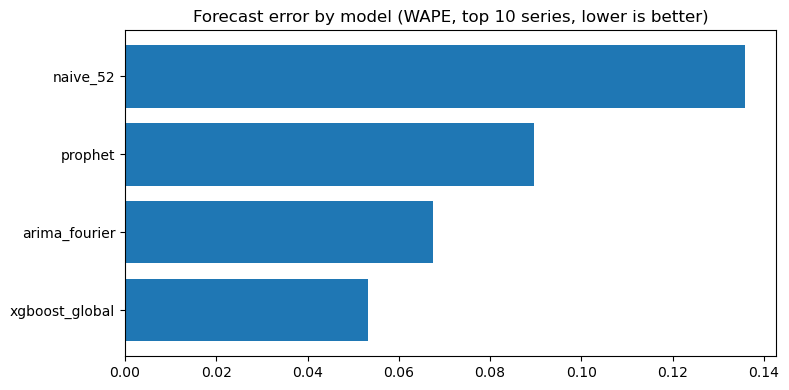

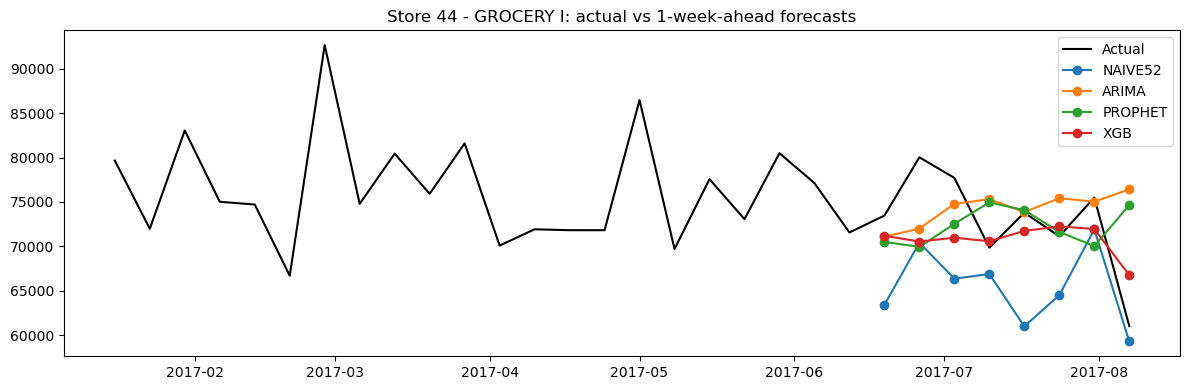

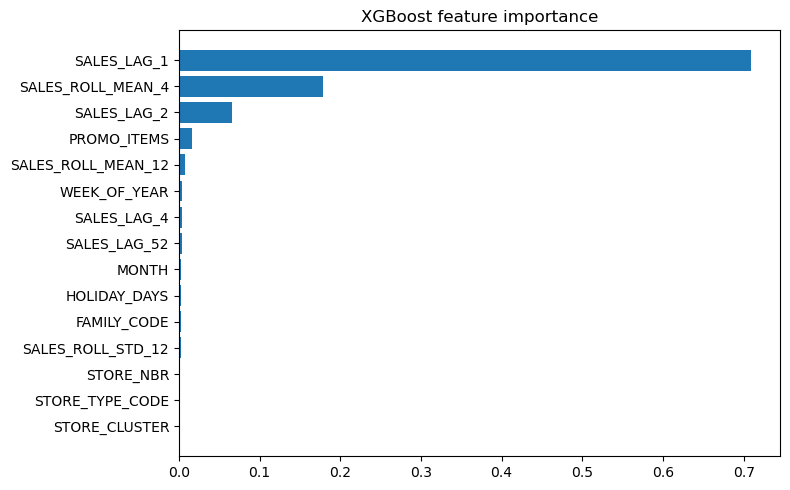

In [8]:
import matplotlib.pyplot as plt

res = pd.DataFrame(results)
summary = res.pivot(index="model", columns="scope", values="wape").round(4)
base = summary.loc["naive_52", "top10"]
summary["improvement_vs_naive_top10"] = ((base - summary["top10"]) / base * 100).round(1).astype(str) + "%"
print(summary)

# Chart 1: WAPE by model on the top 10 series
top10 = res[res["scope"] == "top10"].sort_values("wape")
plt.figure(figsize=(8, 4))
plt.barh(top10["model"], top10["wape"])
plt.title("Forecast error by model (WAPE, top 10 series, lower is better)")
plt.tight_layout(); plt.savefig("docs/images/05_model_comparison.png"); plt.show()

# Chart 2: actual vs forecasts for the biggest series
store, fam = top_list[0]
hist = df[(df["STORE_NBR"] == store) & (df["FAMILY"] == fam)].tail(30)
t = test[(test["STORE_NBR"] == store) & (test["FAMILY"] == fam)]
plt.figure(figsize=(12, 4))
plt.plot(hist["WEEK_START"], hist["SALES"], label="Actual", color="black")
for col in ["PRED_NAIVE52", "PRED_ARIMA", "PRED_PROPHET", "PRED_XGB"]:
    plt.plot(t["WEEK_START"], t[col], marker="o", label=col.replace("PRED_", ""))
plt.title(f"Store {store} - {fam}: actual vs 1-week-ahead forecasts")
plt.legend(); plt.tight_layout(); plt.savefig("docs/images/06_forecast_example.png"); plt.show()

# Chart 3: what drives the XGBoost model
plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values)
plt.title("XGBoost feature importance")
plt.tight_layout(); plt.savefig("docs/images/07_feature_importance.png"); plt.show()

# Save results to Snowflake

In [9]:
from snowflake.connector.pandas_tools import write_pandas

res_out = res.copy()
res_out.columns = [c.upper() for c in res_out.columns]

pred_out = test[KEYS + ["SALES", "IS_TOP", "PRED_NAIVE52", "PRED_ARIMA",
                        "PRED_PROPHET", "PRED_XGB"]].copy()
pred_out["WEEK_START"] = pred_out["WEEK_START"].dt.date
pred_out.columns = [c.upper() for c in pred_out.columns]

conn = get_connection()
for table, frame in [("MODEL_RESULTS", res_out), ("BACKTEST_PREDICTIONS", pred_out)]:
    ok, _, n, _ = write_pandas(conn, frame, table_name=table, database="SALES_DB",
                               schema="ANALYTICS", auto_create_table=True,
                               overwrite=True, quote_identifiers=False)
    print(f"{table:<22} {'OK' if ok else 'FAILED'}  {n:,} rows")
conn.close()

MODEL_RESULTS          OK  6 rows
BACKTEST_PREDICTIONS   OK  14,256 rows
